<a href="https://colab.research.google.com/github/AndreySetiawan98/UAS-NLP/blob/master/TUGAS_ADVANCE_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTALL LIBRARY

In [ ]:
import sys
!{sys.executable} -m pip install transformers
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install torch
!{sys.executable} -m pip install accelerate
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install google-play-scraper
!{sys.executable} -m pip install Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.9 MB/s eta 0:00:00


IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np

import torch

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from google_play_scraper import reviews, Sort

SCRAPING ULASAN TOKOPEDIA

In [ ]:
# ==============================================================================
# 1. IMPORT LIBRARY & PROSES SCRAPING (Sesuai Gambar)
# ==============================================================================
import pandas as pd
from google_play_scraper import Sort, reviews
from google.colab import files

print("Scraping 2000 ulasan Tokopedia...")

# Mengambil ulasan aplikasi Tokopedia dari Google Play Store
result, _ = reviews(
    'com.tokopedia.tkpd',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

# Memasukkan hasil scraping ke DataFrame dan hanya mengambil kolom 'content'
df_raw = pd.DataFrame(result)[['content']]

# Mengubah nama kolom 'content' menjadi 'teks'
df_raw.rename(columns={'content': 'teks'}, inplace=True)

# Menampilkan 5 baris pertama ulasan
print("\nMenampilkan 5 data teratas:")
display(df_raw.head())

# 2. PROSES SIMPAN & DOWNLOAD SEBAGAI FILE CSV
nama_file = "dataset_ulasan.csv"

# Menyimpan ke file CSV dengan encoding utf-8-sig agar karakter terbaca rapi di Excel
df_raw.to_csv(nama_file, index=False, encoding='utf-8-sig')

print(f"\n[✓] Berhasil menyimpan data ke {nama_file}!")
print("[*] Memulai proses download otomatis ke komputer lokal Anda...")

# Fungsi khusus Google Colab untuk mendownload langsung ke laptop/PC Anda
files.download(nama_file)

Scraping 2000 ulasan Tokopedia...

Menampilkan 5 data teratas:


,teks
0,Tokopedia mantap👍
1,perdana download makai tokped dapat promo disk...
2,"makin parah sekarang Tokopedia, dimulai dari p..."
3,mantapp
4,fitur cod nya gabisa dipakek



[✓] Berhasil menyimpan data ke dataset_ulasan.csv!
[*] Memulai proses download otomatis ke komputer lokal Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.upload()

Saving dataset_ulasan(1).csv to dataset_ulasan(1).csv


{'dataset_ulasan(1).csv': b'\xef\xbb\xbfteks\nTokopedia mantap\xf0\x9f\x91\x8d\n"perdana download makai tokped dapat promo diskon besar, pas mau di cek out gk bisa di gunakan harus beli tanpa promo, marketing asu"\n"makin parah sekarang Tokopedia, dimulai dari pencairan yang lelet, sekarang fitnah pencairan uang penjualan barang katanya fake order, uangnya Angus, gitu amat Tokopedia butuh uang nya"\nmantapp\nfitur cod nya gabisa dipakek\nmantap\nsangat susah untuk metode pembayaran lewat saldo Tokopedia untuk pembayaran di saller mohon supaya di permudah fiturnya\nbagus\n"pelayanan bagus dan amanah ,terima kasih."\nvouchernya ada tapi gabisa dipake dan harga barang sama ongkirnya sangat mahal. mending pake shopee hahay\n"Kebanyakan error, diskon masih aktif tapi pas dipasang terus di CO malah gabisaa!!"\nkacauuu tiap belanjaa bayar lewat qriss pesanan tiba tiba gagal oleh kurir yang sama uang refund pun udah di tunggu tiga hari engga ada pengembalian\n"ngebug aplikasinya, di awal harga

In [ ]:
df = pd.read_csv("dataset_ulasan.csv")

df.head()

,teks
0,Tokopedia mantap👍
1,perdana download makai tokped dapat promo disk...
2,"makin parah sekarang Tokopedia, dimulai dari p..."
3,mantapp
4,fitur cod nya gabisa dipakek


DATA PREPROCESSING

In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword_factory = StopWordRemoverFactory()
custom_stopwords = stopword_factory.get_stop_words() + ['nya', 'sih', 'dong', 'ya', 'kak', 'min', 'admin', 'yg', 'di', 'ke', 'buat', 'aja', 'tokopedia', 'tokped']

slangwords = {
    "ongkir": "biaya kirim", "resi": "nomor kirim", "cod": "bayar ditempat",
    "lemot": "lambat", "gercep": "cepat", "gak": "tidak", "ga": "tidak", "nggak": "tidak",
    "bgt": "banget", "udah": "sudah", "dapet": "dapat", "makasih": "terima kasih",
    "app": "aplikasi", "login": "masuk", "update": "perbarui", "eror": "error",
    "seller": "penjual", "ori": "asli", "kw": "palsu", "retur": "kembali barang"
}

def text_preprocessing_pipeline(text):
    text = str(text).lower()
    text = re.sub(r'@[A-Za-z0-9_]+|#[A-Za-z0-9_]+|RT[\s]+|https?://\S+|www\.\S+|[^A-Za-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    fixed_words = [slangwords.get(word, word) for word in words]
    tokens = [word for word in fixed_words if word not in custom_stopwords]
    return stemmer.stem(" ".join(tokens))

print("Menerapkan preprocessing...")
df_raw['teks_bersih'] = df_raw['teks'].apply(text_preprocessing_pipeline)

Menerapkan preprocessing...


ENCODING LABEL SENTIMEN

In [ ]:
# angka 0 = negatif
# angka 1 = netral
# angka 2 = positif
# 1. Definisikan kamus kata kunci untuk Aspek
kamus_aspek = {
    'Aplikasi': ['aplikasi', 'apps', 'web', 'sistem', 'fitur', 'update', 'ui', 'ux', 'tampilan', 'crash', 'lemot', 'bug'],
    'Harga': ['harga', 'mahal', 'murah', 'promo', 'diskon', 'ongkir', 'gratis', 'cashback', 'biaya', 'admin'],
    'Pelayanan': ['seller', 'penjual', 'toko', 'admin', 'chat', 'respon', 'ramah', 'cs', 'customer service'],
    'Pengiriman': ['kurir', 'kirim', 'paket', 'pengiriman', 'cepat', 'lama', 'lambat', 'ekspedisi', 'antar']
}

# 2. Definisikan kamus kata kunci untuk Sentimen
kata_positif = ['bagus', 'puas', 'suka', 'mantap', 'cepat', 'ramah', 'murah', 'membantu', 'mudah', 'oke', 'top']
kata_negatif = ['kecewa', 'jelek', 'buruk', 'lama', 'lambat', 'mahal', 'error', 'lag', 'lemot', 'rugi', 'kesal']

# 3. Fungsi pemecah teks ulasan menjadi baris aspek-sentimen
def konversi_ke_absa(row):
    teks_lower = str(row['teks']).lower()
    baris_absa = []

    for aspek, keywords in kamus_aspek.items():
        if any(keyword in teks_lower for keyword in keywords):
            skor = 0
            for pos in kata_positif:
                if pos in teks_lower: skor += 1
            for neg in kata_negatif:
                if neg in teks_lower: skor -= 1

            if skor > 0:   label = 2
            elif skor < 0: label = 0
            else:          label = 1

            baris_absa.append({
                'teks': row['teks'],
                'aspek': aspek,
                'label': label
            })
    return baris_absa

# 4. Eksekusi pemrosesan data dari DataFrame CSV
data_absa = []
for _, row in df_raw.iterrows():
    hasil_ekstraksi = konversi_ke_absa(row)
    if hasil_ekstraksi:
        data_absa.extend(hasil_ekstraksi)

df_absa = pd.DataFrame(data_absa)
print(f"[✓] Berhasil membentuk {len(df_absa)} pasangan aspek-sentimen dari CSV Anda.")
print("\nContoh Hasil Format ABSA:")
df_absa.head(5)

[✓] Berhasil membentuk 1432 pasangan aspek-sentimen dari CSV Anda.

Contoh Hasil Format ABSA:


,teks,aspek,label
0,Tokopedia mantap👍,Pelayanan,2
1,perdana download makai tokped dapat promo disk...,Harga,1
2,"makin parah sekarang Tokopedia, dimulai dari p...",Pelayanan,1
3,fitur cod nya gabisa dipakek,Aplikasi,1
4,sangat susah untuk metode pembayaran lewat sal...,Aplikasi,2


TOKENISASI INDOBERT

In [ ]:
# 1. Load Tokenizer bawaan IndoBERT
model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Bagi data (80% Train, 20% Validasi)
train_df, val_df = train_test_split(df_absa, test_size=0.2, random_state=42)

# 3. Buat struktur Dataset standar PyTorch untuk Hugging Face
class CSVABSADataset(torch.utils.data.Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Menggabungkan TEKS dan ASPEK berdampingan sebagai Sentence-Pair input BERT
        tokenized_output = tokenizer(
            str(self.df.loc[idx, 'teks']),
            str(self.df.loc[idx, 'aspek']),
            padding="max_length",
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        inputs = {key: val.squeeze(0) for key, val in tokenized_output.items()}
        inputs['labels'] = torch.tensor(self.df.loc[idx, 'label'], dtype=torch.long)
        return inputs

# 4. Inisialisasi objek dataset
train_dataset = CSVABSADataset(train_df)
val_dataset = CSVABSADataset(val_df)

print(f"[✓] Pemisahan selesai. Data Train: {len(train_df)} | Data Validasi: {len(val_df)}")
print("[✓] Dataset dari CSV siap digunakan! Anda tinggal melanjutkan ke pembuatan objek Model IndoBERT dan Fine-Tuning.")

[✓] Pemisahan selesai. Data Train: 1145 | Data Validasi: 287
[✓] Dataset dari CSV siap digunakan! Anda tinggal melanjutkan ke pembuatan objek Model IndoBERT dan Fine-Tuning.


INISIALISASI MODEL DAN FINE TUNING

In [ ]:
# Install the 'evaluate' library
!pip install evaluate

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch # Import torch to use torch.device

# Define the device for model training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model name (was previously defined in another cell)
model_name = "indobenchmark/indobert-base-p1"

# 1. Load Model Klasifikasi IndoBERT (3 Label: 0=Negatif, 1=Netral, 2=Positif)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
model.to(device)

# 2. Ambil metrik evaluasi Akurasi & F1-Score
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1);

    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

# 3. Atur Parameter Training
training_args = TrainingArguments(
    output_dir="./hasil_absa",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=10,
)

# 4. Inisialisasi Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 5. Jalankan Proses Training
print("[*] Memulai Proses Fine-Tuning IndoBERT (Ini akan memakan waktu beberapa menit)...")
trainer.train()
print("[✓] Model IndoBERT selesai dilatih!")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[*] Memulai Proses Fine-Tuning IndoBERT (Ini akan memakan waktu beberapa menit)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.513532,0.409183,0.836237,0.840969
2,0.469752,0.374360,0.885017,0.887489
3,0.199812,0.231577,0.951220,0.951003
4,0.001466,0.201600,0.954704,0.954919
5,0.000639,0.241816,0.958188,0.959204
6,0.000441,0.228484,0.958188,0.959221
7,0.000388,0.236969,0.965157,0.966511
8,0.000328,0.237358,0.958188,0.958969
9,0.000263,0.244123,0.958188,0.959734
10,0.000268,0.244388,0.958188,0.959734


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[✓] Model IndoBERT selesai dilatih!


EVALUASI AKHIR

[*] Mengevaluasi model pada data validasi...



================ PERFORMA MODEL INDOBERT ================
              precision    recall  f1-score   support

     Negatif       0.96      0.98      0.97        88
      Netral       0.94      0.96      0.95       120
     Positif       0.97      0.92      0.95        79

    accuracy                           0.95       287
   macro avg       0.96      0.95      0.95       287
weighted avg       0.96      0.95      0.95       287




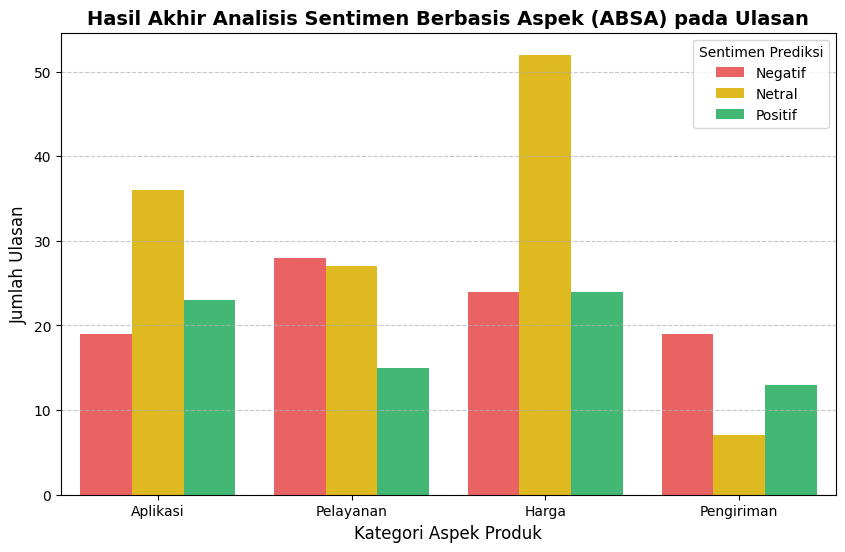

[✓] File 'hasil_akhir_prediksi_absa.csv' berhasil dibuat. Anda dapat melihatnya di folder files Colab.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("[*] Mengevaluasi model pada data validasi...")

# 1. Lakukan prediksi pada dataset validasi
predictions_output = trainer.predict(val_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = val_df['label'].values

# 2. Tampilkan Classification Report
target_names = ['Negatif', 'Netral', 'Positif']
print("\n================ PERFORMA MODEL INDOBERT ================")
print(classification_report(y_true, y_pred, target_names=target_names))
print("=========================================================\n")

# 3. VISUALISASI HASIL AKHIR: Distribusi Sentimen per Aspek
# Kita tambahkan kolom prediksi model ke dataframe validasi untuk dianalisis
val_df['prediksi_sentimen'] = [target_names[p] for p in y_pred]

# Tentukan urutan label agar pemasangan warna di palette tidak tertukar
urutan_sentimen = ['Negatif', 'Netral', 'Positif']

# Tentukan warna yang sesuai dengan urutan_sentimen diatas:
# Negatif = Merah (#ff4d4d), Netral = Kuning (#ffcc00), Positif = Hijau (#2ecc71)
warna_sentimen = ['#ff4d4d', '#ffcc00', '#2ecc71']

# Membuat grafik batang bertumpuk (Grouped Bar Chart)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=val_df,
    x='aspek',
    hue='prediksi_sentimen',
    hue_order=urutan_sentimen, # Mengunci urutan tampilan legasi/batang
    palette=warna_sentimen     # Memasang warna sesuai urutan terkunci
)

plt.title('Hasil Akhir Analisis Sentimen Berbasis Aspek (ABSA) pada Ulasan', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Aspek Produk', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.legend(title='Sentimen Prediksi')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik di Google Colab
plt.show()

# 4. Menyimpan Hasil Akhir Prediksi Validasi ke CSV
val_df.to_csv("hasil_akhir_prediksi_absa.csv", index=False, encoding="utf-8-sig")
print("[✓] File 'hasil_akhir_prediksi_absa.csv' berhasil dibuat. Anda dapat melihatnya di folder files Colab.")

INTERFACE

In [1]:
# ============================================================
# INTERFACE GRADIO: MAPPING SENTIMEN TOKOPEDIA
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import gradio as gr

print("[*] Mengonfigurasi ulang sistem dengan perbaikan urutan label...")

# 1. KAMUS ASPEK (Tetap sama)
KAMUS_ASPEK = {
    'Aplikasi': ['aplikasi', 'apps', 'web', 'sistem', 'fitur', 'update', 'ui', 'ux', 'tampilan', 'crash', 'lemot', 'bug'],
    'Harga': ['harga', 'mahal', 'murah', 'promo', 'diskon', 'ongkir', 'gratis', 'cashback', 'biaya', 'admin'],
    'Pelayanan': ['seller', 'penjual', 'toko', 'admin', 'chat', 'respon', 'ramah', 'cs', 'customer service'],
    'Pengiriman': ['kurir', 'kirim', 'paket', 'pengiriman', 'cepat', 'lama', 'lambat', 'ekspedisi', 'antar']
}

# 2. FUNGSI LOGIKA (BACKEND)
def analisa_ulasan_otomatis_fixed(ulasan):
    if not ulasan.strip():
        return "Input teks ulasan tidak boleh kosong.", "Notifikasi: Input Kosong"

    ulasan_lower = ulasan.lower()
    aspek_terdeteksi = []

    # Deteksi aspek berdasarkan kamus kata kunci
    for kategori_aspek, kata_kunci in KAMUS_ASPEK.items():
        for kata in kata_kunci:
            if kata in ulasan_lower:
                aspek_terdeteksi.append(kategori_aspek)
                break

    if not aspek_terdeteksi:
        return "Model tidak dapat menganalisis.", "⚠️ Tidak ada aspek spesifik yang terdeteksi (Gunakan kata seperti: produk, kurir, harga, seller, packing)."

    model.eval()
    hasil_akhir_list = []

    # KUNCI UTAMA: Pastikan indeks ini 100% sama dengan label saat training df!
    # Di data awal kita: 0 = Negatif, 1 = Netral, 2 = Positif
    MAPPING_LABEL = {
        0: "🔴 NEGATIF",
        1: "🟡 NETRAL",
        2: "🟢 POSITIF"
    }

    for asp in aspek_terdeteksi:
        # Tokenisasi pasangan Kalimat + Aspek
        inputs = tokenizer(ulasan, asp, return_tensors="pt", padding=True, truncation=True, max_length=128)

        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        token_type_ids = inputs['token_type_ids'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
            logits = outputs.logits

            # Ubah logits menjadi probabilitas (0 sampai 1)
            probabilities = F.softmax(logits, dim=1).flatten()

            # Ambil indeks dengan nilai probabilitas tertinggi
            prediction = torch.argmax(probabilities).item()

        sentimen_label = MAPPING_LABEL[prediction]
        skor_keyakinan = probabilities[prediction].item() * 100

        # Tambahkan teks hasil visualisasi ke list output
        hasil_akhir_list.append(
            f"📌 Aspek [{asp.upper()}]:\n"
            f"  Hasil Akhir -> {sentimen_label} ({skor_keyakinan:.2f}% yakin)\n"
            f"  [Detail Skor -> Negatif: {probabilities[0].item()*100:.1f}% | Netral: {probabilities[1].item()*100:.1f}% | Positif: {probabilities[2].item()*100:.1f}%]\n"
        )

    kesimpulan_sentimen = "\n".join(hasil_akhir_list)
    daftar_aspek_teks = ", ".join([a.upper() for a in aspek_terdeteksi])

    return kesimpulan_sentimen, f"✅ Berhasil mengekstrak aspek: {daftar_aspek_teks}"


# --- 3. RUNTIME UI (GRADIO BLOCKS) ---
with gr.Blocks(theme=gr.themes.Base()) as tokopedia_fixed_app:
    gr.Markdown("# 🛒 Tokopedia Smart ABSA")

    with gr.Row():
        with gr.Column():
            input_review = gr.Textbox(
                lines=4,
                label="Teks Ulasan Tokopedia",
                placeholder="Contoh: Barangnya jelek bgt langsung rusak pas dibuka, tapi kurirnya ramah."
            )
            btn_run = gr.Button("Analisis Sentimen", variant="primary")

        with gr.Column():
            out_status = gr.Textbox(label="Status Ekstraktor Aspek", interactive=False)
            out_result = gr.Textbox(lines=8, label="Hasil Analisis Sentimen", interactive=False)

    btn_run.click(fn=analisa_ulasan_otomatis_fixed, inputs=[input_review], outputs=[out_result, out_status])

tokopedia_fixed_app.launch(share=True, debug=True)


[*] Mengonfigurasi ulang sistem dengan perbaikan urutan label...


/tmp/ipykernel_639/3012221845.py:84: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Base()) as tokopedia_fixed_app:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2ff97b7590c29be37b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2ff97b7590c29be37b.gradio.live
